0


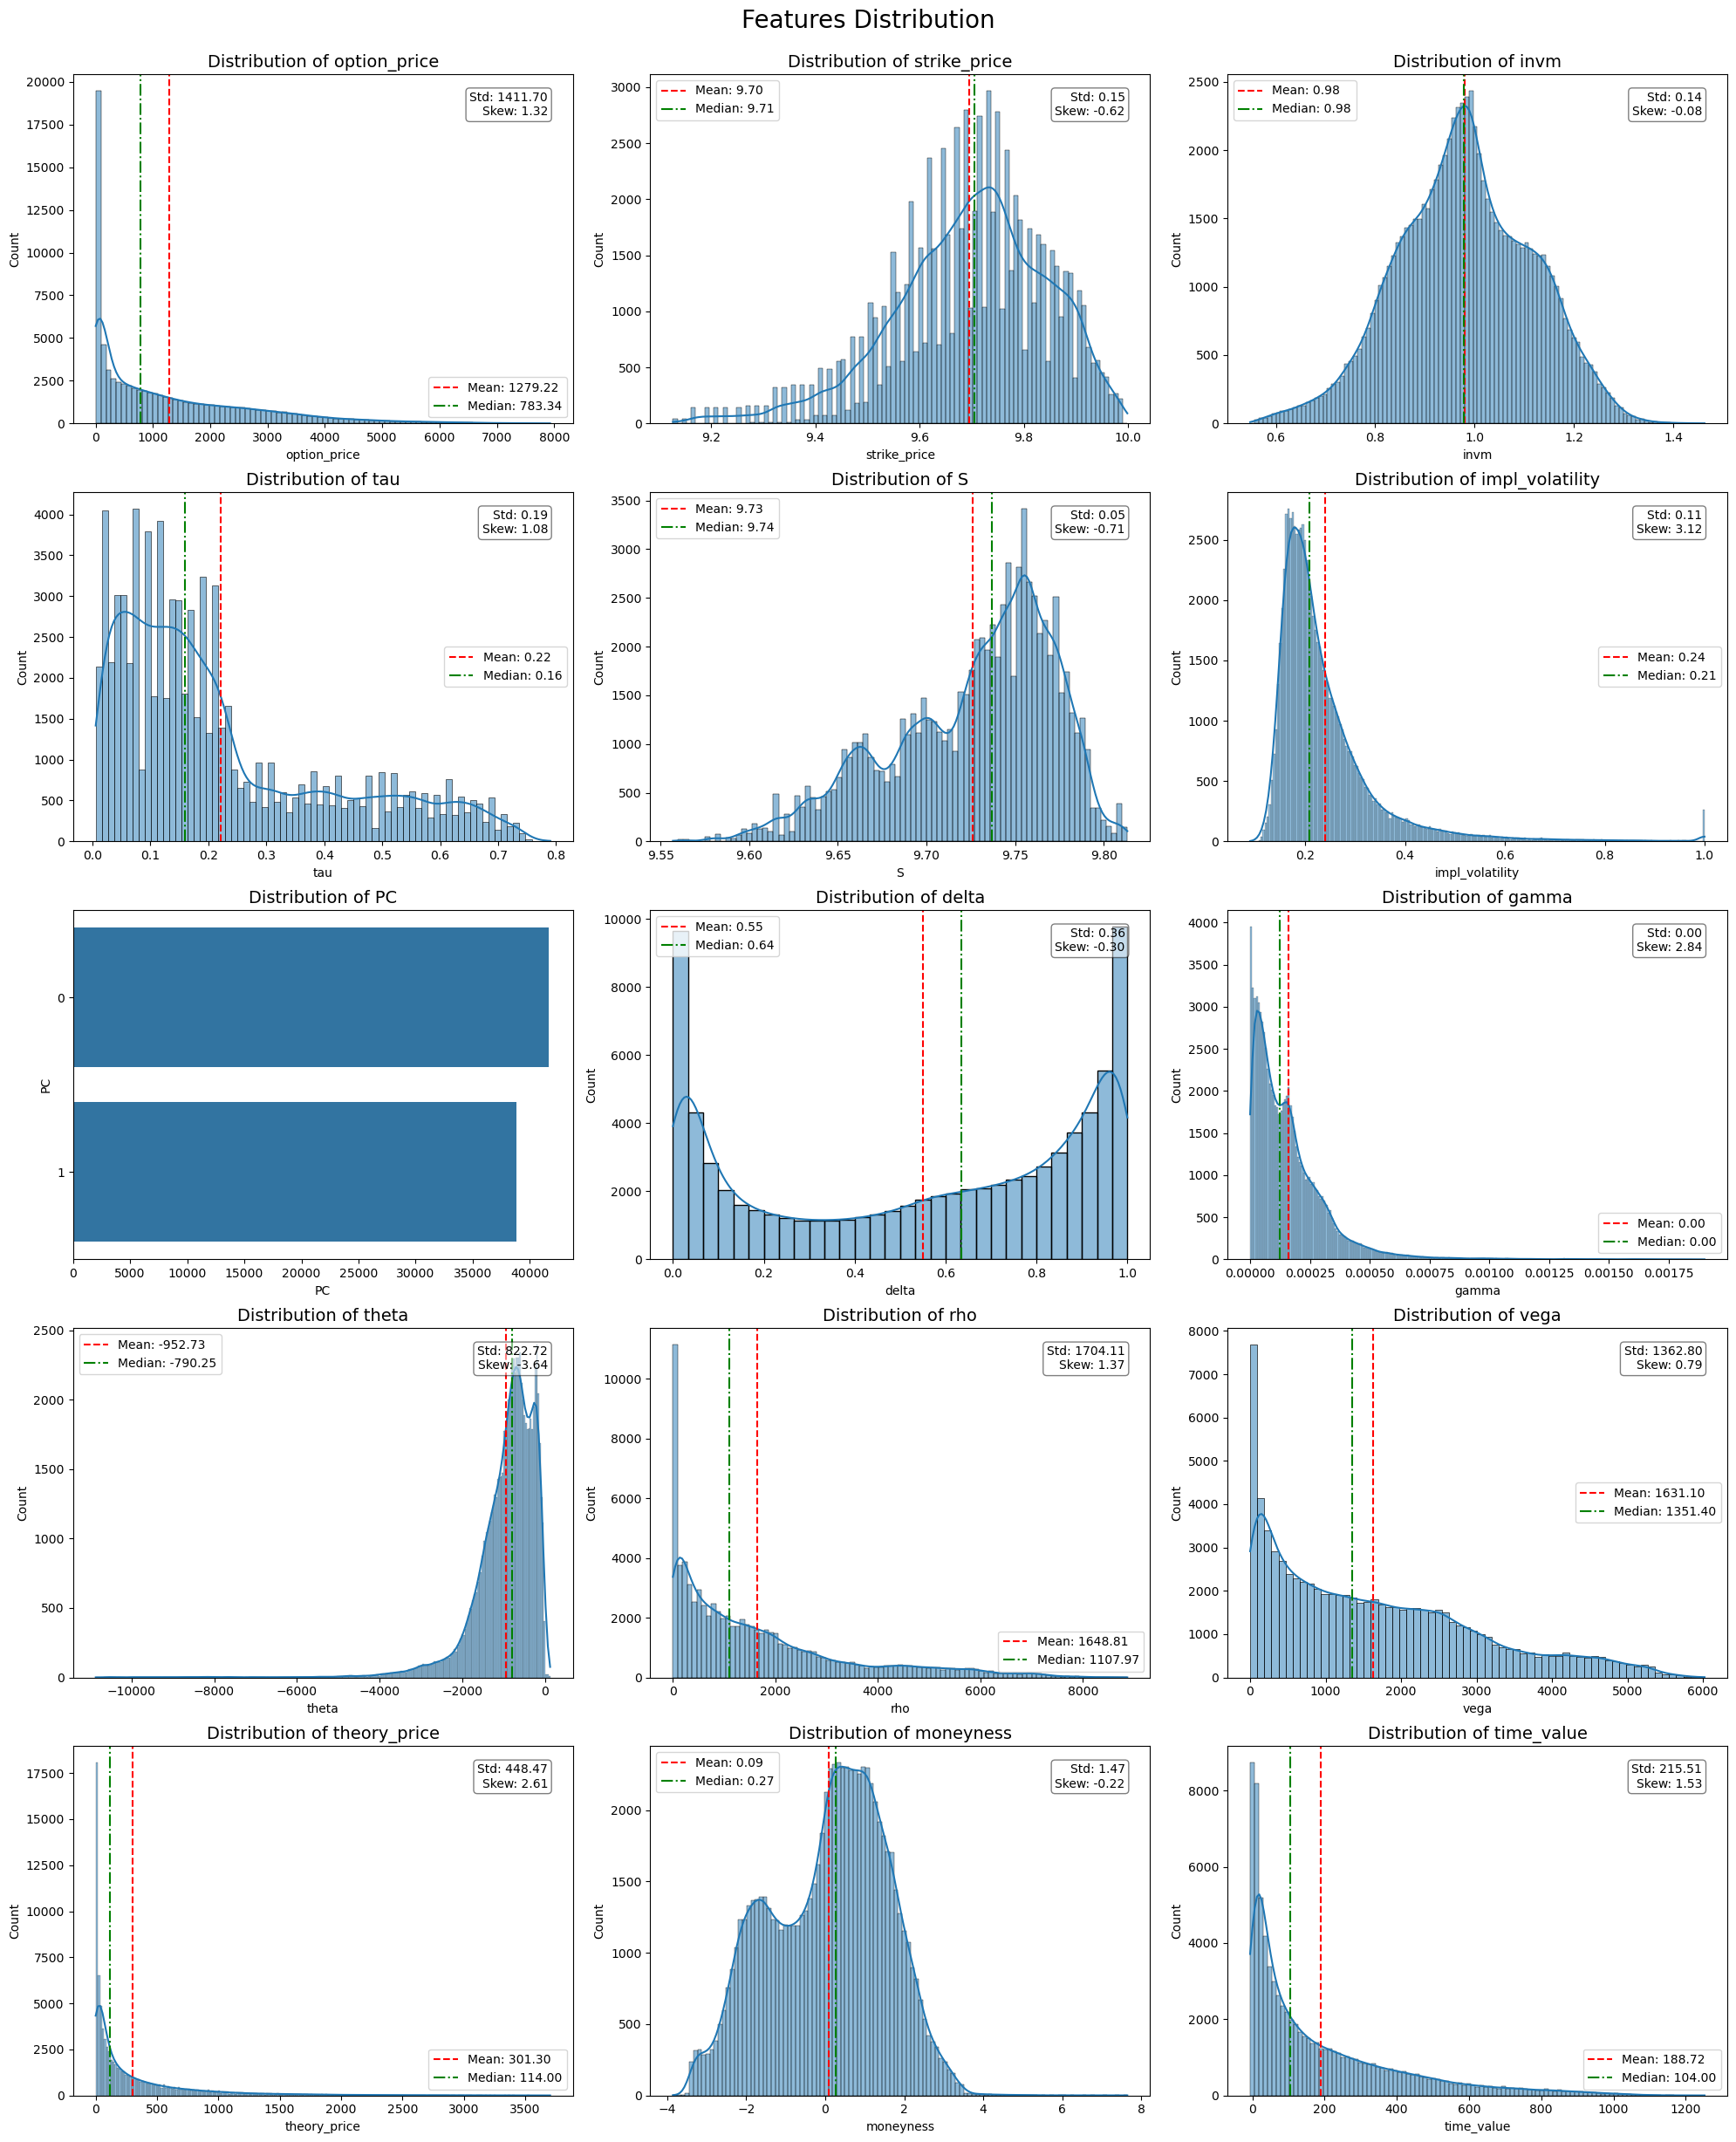

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 讀取CSV檔案 (請替換為您的檔案路徑)
df = pd.read_csv(r"/Users/chuchu/Desktop/option_pricing_thesis_project/3D-Tensor-based-Deep-Learning-Models-for-Predicting-Option-Price-main/data/prs_dataset_mpf.csv")

# 設置圖表風格和大小
plt.rcParams['figure.figsize'] = (20, 15)

# 主要特徵的分佈圖函數
def plot_distributions(dataframe, features, rows, cols):
    fig, axes = plt.subplots(rows, cols, figsize=(20, 5*rows))
    axes = axes.flatten()
    
    for i, feature in enumerate(features):
        # 直方圖與密度圖
        if dataframe[feature].nunique() > 10:  # 連續特徵
            sns.histplot(dataframe[feature], kde=True, ax=axes[i])
            
            # 添加基本統計資訊
            mean_val = dataframe[feature].mean()
            median_val = dataframe[feature].median()
            std_val = dataframe[feature].std()
            skew_val = dataframe[feature].skew()
            
            axes[i].axvline(mean_val, color='r', linestyle='--', label=f'Mean: {mean_val:.2f}')
            axes[i].axvline(median_val, color='g', linestyle='-.', label=f'Median: {median_val:.2f}')
            
            stat_text = f"Std: {std_val:.2f}\nSkew: {skew_val:.2f}"
            axes[i].text(0.95, 0.95, stat_text, transform=axes[i].transAxes, 
                        verticalalignment='top', horizontalalignment='right',
                        bbox={'boxstyle':'round', 'facecolor':'white', 'alpha':0.5})
        else:  # 離散特徵
            sns.countplot(y=feature, data=dataframe, ax=axes[i])
        
        axes[i].set_title(f'Distribution of {feature}', fontsize=14)
        axes[i].set_xlabel(feature)
        axes[i].tick_params(axis='both', labelsize=10)
        if dataframe[feature].nunique() > 10:
            axes[i].legend()
    
    # 隱藏未使用的子圖
    for j in range(i+1, rows*cols):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.suptitle("Features Distribution", fontsize=20)
    plt.subplots_adjust(top=0.95)
    plt.show()

# 選擇主要特徵分析
key_features = [
    'option_price', 'strike_price', 'invm', 'tau', 'S', 
    'impl_volatility', 'PC', 'delta', 'gamma', 'theta', 
    'rho', 'vega', 'theory_price', 'moneyness', 'time_value'
]

# 過濾可能的異常值以獲得更好的視覺化
df_filtered = df.copy()
for feature in key_features:
    if feature in df.columns and df[feature].dtype in [np.float64, np.int64]:
        # 使用 IQR 方法過濾極端異常值
        Q1 = df[feature].quantile(0.01)
        Q3 = df[feature].quantile(0.99)
        IQR = Q3 - Q1
        df_filtered = df_filtered[(df_filtered[feature] >= Q1 - 1.5 * IQR) & 
                                 (df_filtered[feature] <= Q3 + 1.5 * IQR)]

# 計算列數和行數
num_features = len(key_features)
cols = 3
rows = (num_features + cols - 1) // cols

# 繪製分佈圖
plot_distributions(df_filtered, key_features, rows, cols)